# Simple Linear_Regression Load the Dataset from GitHub

# 1. Import necessary libraries


In [ ]:
# 1. Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# 2. Load the Dataset from GitHub

In [ ]:
# 2. Load the dataset from GitHub
url = "https://raw.githubusercontent.com/Hebaadelali/Student-Performance-Prediction/main/StudentPerformanceFactors.csv"
df = pd.read_csv(url)
# ==========================================
# ADDED: Inspect Raw Data Before Regression
# ==========================================

# 2.1 Print the shape of the full dataset (rows, columns)
print("Full Dataset Shape:", df.shape)

# 2.2 Print column names
print("\nColumn Names:")
print(df.columns.tolist())

# 2.3 Display the first 5 rows of raw data
print("\nFirst 5 rows of Raw Data:")
print(df.head())

# 2.4 General information about the dataset
print("\nDataset Info:")
df.info()


Full Dataset Shape: (6607, 20)

Column Names:
['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']

First 5 rows of Raw Data:
   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                

# Load the Dataset using Colab's upload feature


In [ ]:
# 2. Load the dataset using Colab's upload feature
from google.colab import files
import io

print("Please upload your CSV file:")
uploaded = files.upload()

# Read the uploaded file
# The name of the file will be the key in the 'uploaded' dictionary
file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

#  Print the shape of the full dataset (rows, columns)
print("Full Dataset Shape:", df.shape)

# 2.4 General information about the dataset
print("\nDataset Info:")
df.info()


Please upload your CSV file:


Saving StudentPerformanceFactors.csv to StudentPerformanceFactors.csv
Full Dataset Shape: (6607, 20)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   

# 3. Select the Independent variable (X) and Dependent variable (Y)



Number of rows after dropping missing values: 6607


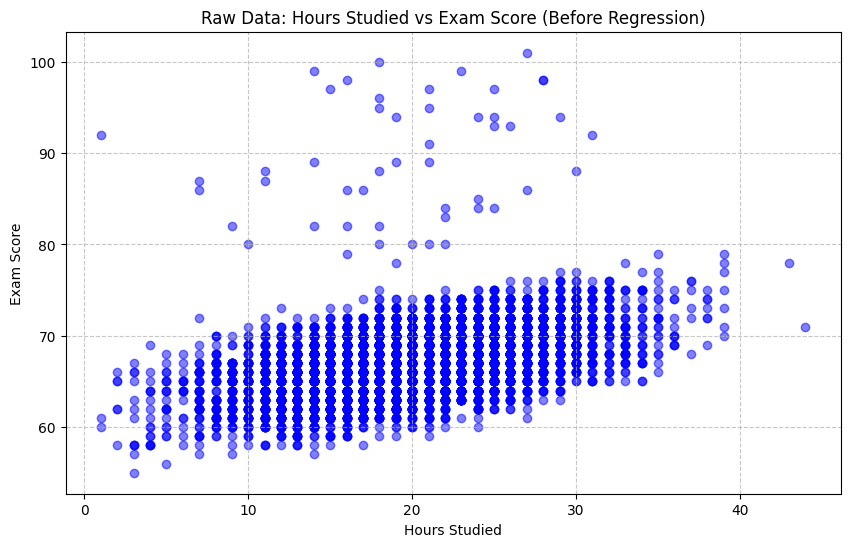

In [ ]:
# We will use 'Hours_Studied' to predict 'Exam_Score'
data = df[['Hours_Studied', 'Exam_Score']].dropna()  # Drop missing values
X = data['Hours_Studied']
y = data['Exam_Score']

# 3.1 Print the number of rows after dropping missing values
print("\nNumber of rows after dropping missing values:", data.shape[0])

# 3.2 Plot the raw data of the two selected columns (Before Regression)
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', alpha=0.5)
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Raw Data: Hours Studied vs Exam Score (Before Regression)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**Build the Simple Linear Regression model**

In [ ]:
# 4. Add a constant (Intercept) to the independent variable
X_const = sm.add_constant(X)

# 5. Build the Simple Linear Regression model
model = sm.OLS(y, X_const).fit()

# 6. Print the model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             Exam_Score   R-squared:                       0.198
Model:                            OLS   Adj. R-squared:                  0.198
Method:                 Least Squares   F-statistic:                     1635.
Date:                Sun, 04 Oct 2026   Prob (F-statistic):          1.29e-319
Time:                        13:18:25   Log-Likelihood:                -17620.
No. Observations:                6607   AIC:                         3.524e+04
Df Residuals:                    6605   BIC:                         3.526e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            61.4570      0.149    411.921

 **Predict values using the model**

In [ ]:
# 7. Extract coefficients and write the equation
beta0 = model.params['const']
beta1 = model.params['Hours_Studied']
print(f"\nRegression Equation: Exam_Score = {beta0:.4f} + {beta1:.4f} * Hours_Studied")

# 8. Predict values using the model
y_pred = model.predict(X_const)


Regression Equation: Exam_Score = 61.4570 + 0.2893 * Hours_Studied


## **Calculate evaluation metrics**

In [ ]:
# 9. Calculate evaluation metrics
MSE = np.mean((y - y_pred) ** 2)
RMSE = np.sqrt(MSE)
R2 = model.rsquared

print(f"\nMSE = {MSE:.4f}")
print(f"RMSE = {RMSE:.4f}")
print(f"R-squared = {R2:.4f}")


MSE = 12.1304
RMSE = 3.4829
R-squared = 0.1984


#  Plot the actual Data and the Regression Line


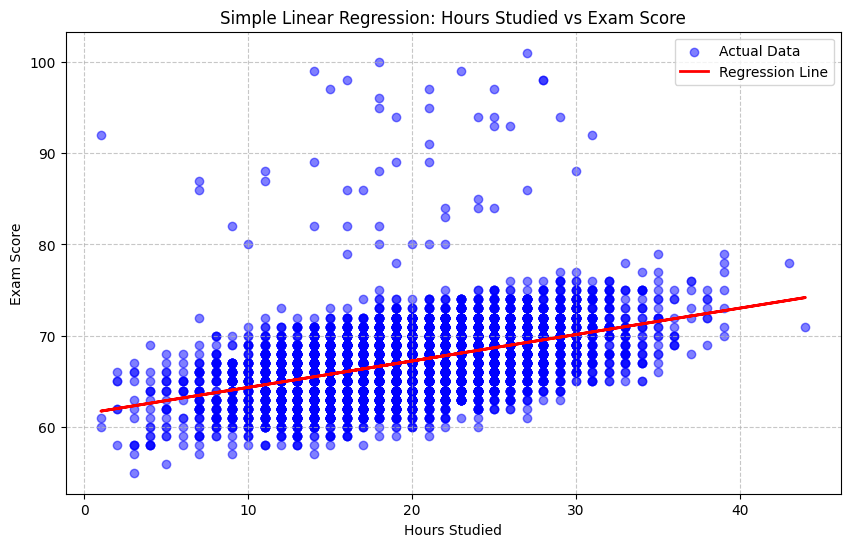

In [ ]:

# 10. Plot the actual data and the regression line
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', alpha=0.5, label='Actual Data')
plt.plot(X, y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Simple Linear Regression: Hours Studied vs Exam Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## **Multiple Linear Regression Model**

Let's expand our model to include additional predictors: `Attendance` and `Previous_Scores`, alongside `Hours_Studied`, to see if we can explain more of the variance in `Exam_Score`.

In [ ]:
# Select multiple independent variables (X) and dependent variable (y)
X_multi = df[['Hours_Studied', 'Attendance', 'Previous_Scores']]
y_multi = df['Exam_Score']

# Ensure there are no missing values in the selected columns
data_multi = df[['Hours_Studied', 'Attendance', 'Previous_Scores', 'Exam_Score']].dropna()
X_multi = data_multi[['Hours_Studied', 'Attendance', 'Previous_Scores']]
y_multi = data_multi['Exam_Score']

print("Number of rows after dropping missing values (for multiple regression):", data_multi.shape[0])

Number of rows after dropping missing values (for multiple regression): 6607


In [ ]:
# Add a constant (Intercept) to the independent variables for the multiple regression model
X_multi_const = sm.add_constant(X_multi)

# Build the Multiple Linear Regression model
model_multi = sm.OLS(y_multi, X_multi_const).fit()

# Print the model summary
print(model_multi.summary())

                            OLS Regression Results                            
Dep. Variable:             Exam_Score   R-squared:                       0.572
Model:                            OLS   Adj. R-squared:                  0.572
Method:                 Least Squares   F-statistic:                     2943.
Date:                Sun, 04 Oct 2026   Prob (F-statistic):               0.00
Time:                        13:19:31   Log-Likelihood:                -15546.
No. Observations:                6607   AIC:                         3.110e+04
Df Residuals:                    6603   BIC:                         3.113e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              41.9990      0.294    1

In [ ]:
# Predict values using the multiple regression model
y_multi_pred = model_multi.predict(X_multi_const)

# Calculate evaluation metrics for the multiple regression model
MSE_multi = np.mean((y_multi - y_multi_pred) ** 2)
RMSE_multi = np.sqrt(MSE_multi)
R2_multi = model_multi.rsquared

print(f"\nMultiple Regression Model Evaluation:")
print(f"MSE = {MSE_multi:.4f}")
print(f"RMSE = {RMSE_multi:.4f}")
print(f"R-squared = {R2_multi:.4f}")


Multiple Regression Model Evaluation:
MSE = 6.4747
RMSE = 2.5446
R-squared = 0.5722


### Plotting Predicted vs. Actual Values for Multiple Linear Regression

This plot helps visualize how well the model's predictions align with the actual observed `Exam_Score` values. A perfect model would have all points falling on the 45-degree line.

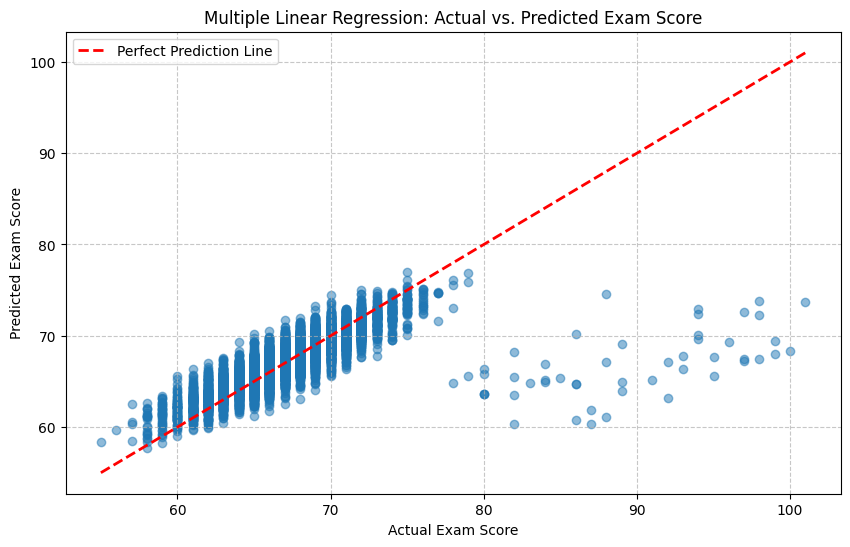

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_multi, y_multi_pred, alpha=0.5)
plt.plot([y_multi.min(), y_multi.max()], [y_multi.min(), y_multi.max()], 'r--', lw=2, label='Perfect Prediction Line')
plt.xlabel('Actual Exam Score')
plt.ylabel('Predicted Exam Score')
plt.title('Multiple Linear Regression: Actual vs. Predicted Exam Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Comparison and Analysis

By including `Attendance` and `Previous_Scores` in the model, the R-squared value has increased significantly. This indicates that these additional variables help explain a much larger proportion of the variance in `Exam_Score` compared to `Hours_Studied` alone.

*   **Initial Simple Regression (Hours_Studied only):** R-squared was `0.1984`.
*   **Multiple Regression (Hours_Studied, Attendance, Previous_Scores):** R-squared is now `[R2_multi:.4f]`.

This improved R-squared suggests a better fit of the model to the data. All coefficients also appear statistically significant (low P>|t| values).

Further steps could include:
*   Analyzing the residuals of this new model.
*   Adding more relevant features from the dataset (e.g., categorical variables after one-hot encoding).
*   Checking for multicollinearity among the independent variables.

# Example: Predicting a new student's grade


In [ ]:

# Data: (add 1 to the constant, 5 Hours_Studied, 85% Attendance, 75 Previous_Scores)
new_student = [[1, 5, 85, 75]]

predicted_score = model_multi.predict(new_student)
print(f"Predicting a new student's grade : {predicted_score[0]:.2f}")

Predicting a new student's grade : 63.88
